## *Proposition de workflow pour le process de données µSAXS*

#### **Problématique**

Les données de cartographie µSAXS (SWING) sont généralement enregistrées en enregistrant toutes les images correspondant à une ligne du scan (une position z) dans un seul et unique fichier h5 (qui contient les images SAXS pour les différentes valeurs de x).
Ainsi, on ne peut plus considérer le fichier h5 comme étant un échantillon unique et moyenner les images qui y sont contenues.

#### **Proposition de workflow**

Le workflow proposé regroupe les étapes suivantes:
- conversion d'un fichier h5 en plusieurs images edf (avec conservation des meta-données, notamment des positions moteurs)
- utilisation du code saxsprocessor en utilisant l'ensemble des fichiers edf comme fichiers uniques
- on écrira ensuite de nouvelles fonctions pour faire les cartographies (de paramètre nématique, d'orientation, etc...)


Dans un premier temps, on décrit le workflow sur un fichier h5 unique. Dans un second temps, nous montrerons les fonctions à utiliser pour tracer la cartographie du paramètre nématique et son orientation à partir d'une série de fichiers h5 correspondant à un même assemblage.



## I/ Test sur fichier unique

Le but de ce test est de montrer comment cela fonctionne. Il y a 

#### **Etape 1: Conversion des fichiers h5 en edf**

On utilise la méthode 'convert2edf' de la classe h5File_SWING, en précisant bien qu'on ne veut PAS moyenner les images (passer l'argument mean=False lors de l'instantiation de la classe).
Remarque: Dans le parser du format edf, le binning est par défaut 1. Par conséquent, la taille des pixels est mutlipliée par les paramètres de binning pendant la conversion en format edf.

In [1]:
%matplotlib widget
from filereaders import h5File_SWING
from utilities import *

# Make pyfai warning silent (optional, but nicer output)
import logging, warnings

logging.getLogger("pyFAI").setLevel(logging.ERROR)
logging.getLogger("fabio").setLevel(logging.ERROR)

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    module="pyFAI"
)


  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\asyncio\base_events.py", line 683, in run_forever
    self._run_once()
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\asyncio\base_events.py", line 2050, in _run_once
    handle._run()
  File "c:\Users\lisab\anaconda3\envs\saxs\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self

L'étape suivante permet de convertir le fichier mask fourni par l'équipe de SWING dans un format compatible avec celui utilisé dans SAXSProcessor (convention pyFAI). 
Le masque fourni étant incomplet (manque le beamstop), on utilise un autre fichier édité avec pyFAI (via SAXS_toolbox, mais c'est une autre histoire).

In [2]:

testfile = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs'

edfpath='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1/'
file = h5File_SWING(testfile,mean = False) # we do not average data contained in this file, we force linescan (step_z=0)


# Convert mask from SWING mask (just to show it is possible)
#mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask_lacroix_jul24.txt'
#mask=file.convert_SWING_mask(maskfile=mask)

# as beamstop is missing on this mask, we use the following file:
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'

# convert h5file to edf files
file.convert2edf(outputdir=edfpath)

print(f'Scan parameters: xstart = {file.position_x_start}, step x: {file.step_x}, zstart={file.position_z_start},step_z:{file.step_z}')


position moteur :
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
step :
[0.04861111]
[0.04004]
180
Raw data shape: (36, 5, 1083, 1035)
info
36
5
0
convert
[[0 0 0 ... 0 0 0]
 [0 0 1 ... 1 0 0]
 [0 0 0 ... 0 0 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
transmission [[0.9679266  0.94129211 0.91000429 0.93426392 0.90742767 0.91749642
  0.96025856 0.98148761 0.9152112  0.9030519  0.95239529 0.90489335
  0.92183397 0.97359155 0.92878473 0.95645738 0.95349483 0.90081538
  0.92122297 0.92759174 0.99613369 0.92964583 0.91601678 0.9082107
  0.93345439 0.89758559 0.93378552 0.94472217 0.94444303 0.92571339
  0.94455993 0.92449746 0.89506643 0.94445187 0.99095034 0.91236202]
 [0.89975864 0.97056351 0.9268131  0.94596873 0.93925673 0.91323606
  0.94220963 0.91672747 0.93606101 0.90042982 0.92124153 

#### **Etape 2: Traitement des fichiers individuels**

Pour l'exemple, on va ici faire un plot de l'évolution du paramètre nématique des figures de diffusion en fonction de la position du moteur x. 
On va d'abord tracer un profil radial large pour trouver une valeur de q d'intérêt pour l'extraction du profil azimuthal et on calculera ensuite le paramètre d'ordre nématique pour chaque image/position x contenue dans le fichier h5.

['C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_0.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_1.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_2.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_3.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_4.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_5.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_6.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_7.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_8.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_Img_0_9.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_1\\S0001_M0099_File_161_I

Text(0, 0.5, 'I(q)')

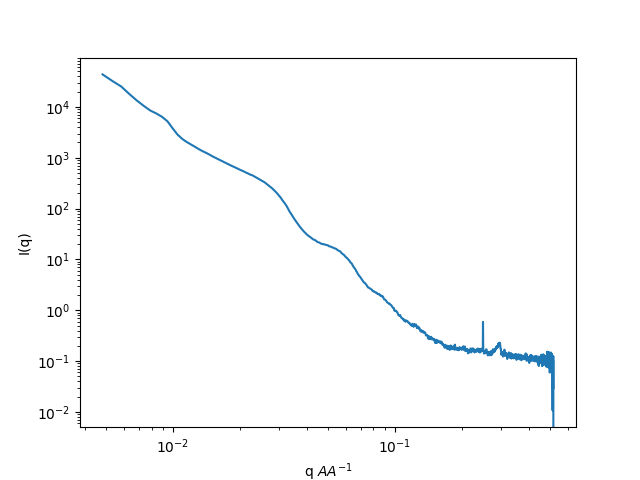

In [3]:
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re

# retrieve the number of points from the h5file
number_of_images = 36*5
file_filter = '*Img*.edf'  # be careful not to include the mask in this list
instrument = 'LGC'

# Establish a list of files
filelist = glob.glob(os.path.join(edfpath,file_filter))

# Sort the file list (we need to define a function)
# files are sorted by File_number.Img 

def parse_img(file):
    match = re.search(r'img_(\d+)_(\d+)', file, re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None  # fichier non conforme

# On filtre : conserve seulement les fichiers valides
valid_files = [f for f in filelist if parse_img(f) is not None]

# On trie uniquement les fichiers valides
sorted_files = sorted(valid_files, key=lambda f: parse_img(f))

print(sorted_files)

def sort_img(file):
    # Recherche un motif du type img_12_34 ou img_001_023
    match = re.search(r'img_(\d+)_(\d+)', file, re.IGNORECASE)
    if not match:
        raise ValueError(f"Format de fichier non reconnu : {file}")
    
    col = int(match.group(1))
    row = int(match.group(2))
    return col, row

# Tri de la liste
#filelist = sorted(filelist, key=sort_img)
#print(filelist)

# tracé du profil radial
file = filelist[0]
proc = SAXSProcessor(file, mask=mask, instrument='LGC') # instrument is set to 'LGC' as we are dealing with edf files now.
q,I = proc.extract_radial_profile(width=360)

plt.figure()
plt.loglog(q,I)
plt.xlabel('q $AA^{-1}$')
plt.ylabel('I(q)')


In [ ]:
from utilities_SWING import *
h5path='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs'
#referencefile='path/to/reference/file'  # --- IGNORE ---
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'

AS = 8.38
diametre = 183
diametre_pd = 0.1421
L_pd=0.1569  
qvalue = 0.02690462

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(
    h5path=h5path,
    mask=mask,
    filelist=sorted_files, 
    qvalue=qvalue,
    threshold=0.05,
    radius=diametre/2,
    L=AS*diametre,
    radius_pd=diametre_pd/2,
    L_pd=L_pd,
    threshold=0.05,
    plot=True,
    apply_mirror=False,
    verbose=True,
    nb_ligne=5,  # A integrer proprement dans la fonction
    nb_colonne=35
    )

In [ ]:
from utilities_SWING import *
h5path='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs'
#referencefile='path/to/reference/file'  # --- IGNORE ---
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(
    h5path=h5path,
    mask=mask,
    filelist=sorted_files, 
    qvalue=0.034,
    threshold=0.05,
    plot=True,
    apply_mirror=False,
    verbose=True)

### Step 5/7
**Computing nematic order parameter (parallel)**

[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   3 tasks      | elapsed:  3.7min
[Parallel(n_jobs=11)]: Done  10 tasks      | elapsed:  3.7min
[Parallel(n_jobs=11)]: Done  19 tasks      | elapsed:  7.2min
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed: 10.7min
[Parallel(n_jobs=11)]: Done  39 tasks      | elapsed: 15.8min
[Parallel(n_jobs=11)]: Done  50 tasks      | elapsed: 19.4min
[Parallel(n_jobs=11)]: Done  63 tasks      | elapsed: 23.0min
[Parallel(n_jobs=11)]: Done  76 tasks      | elapsed: 26.7min
[Parallel(n_jobs=11)]: Done  91 tasks      | elapsed: 33.8min
[Parallel(n_jobs=11)]: Done 106 tasks      | elapsed: 37.8min
[Parallel(n_jobs=11)]: Done 123 tasks      | elapsed: 45.5min
[Parallel(n_jobs=11)]: Done 140 tasks      | elapsed: 55.1min
[Parallel(n_jobs=11)]: Done 159 tasks      | elapsed: 63.0min
[Parallel(n_jobs=11)]: Done 178 tasks      | elapsed: 67.8min
[Parallel(n_jobs=11)]: Done 199 tasks      | elapsed: 8

#### Determination du paramètre nématique

Ici, on va utiliser la fonction "compute_nematic_parameter" disponible dans le fichier utilities.py. 
Cette fonction prend comme arguments les paramètres de taille utiles au calcul du facteur de forme (ici on utilise les paramètres par défaut). Pour le calcul du facteur de forme, l'orientation du cylindre est déterminée à partir de l'image SAXS (= maximum d'intensité sur le profil azimuthal) 
Voici la liste des arguments de la fonction "compute_nematic_parameter":

    *** Args ***

    processor: SAXSProceesor instance
        SAXSProcessor instance (mandatory)

    qvalue: float
        q value of interest at which azimuthal profile is extracted

    threshold: float
        relative value to defin the q range for azimuthal profile extraction

    radius: float
        Cylinder radius for form factor caclulation

    L: float
        Cylinder length for form factor calculation

    radius_pd, L_pd: float
        Polydispersity ratio for radius and length

    plot : bool
        Plot form factor and fitting results

    apply_mirror: bool
        Apply mirror symmetry to incomplete exp azimuthal profile

    *** Returns ****
    results : dict
        {'I0': I0_opt,
        'm': m_opt,
        'x0': x0_opt,
        'a': a_opt,
        'b': b_opt,
        'S': S_opt,
        'R2': r_squared,
        'I_model': I_model}
    


- 1. Extraction profil azimuthal


************************************************************************************************************************

 Processing file 1 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_0.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_0.png
Main nanorod orientation is 5.006972872275682

Computing cylinder form factor...


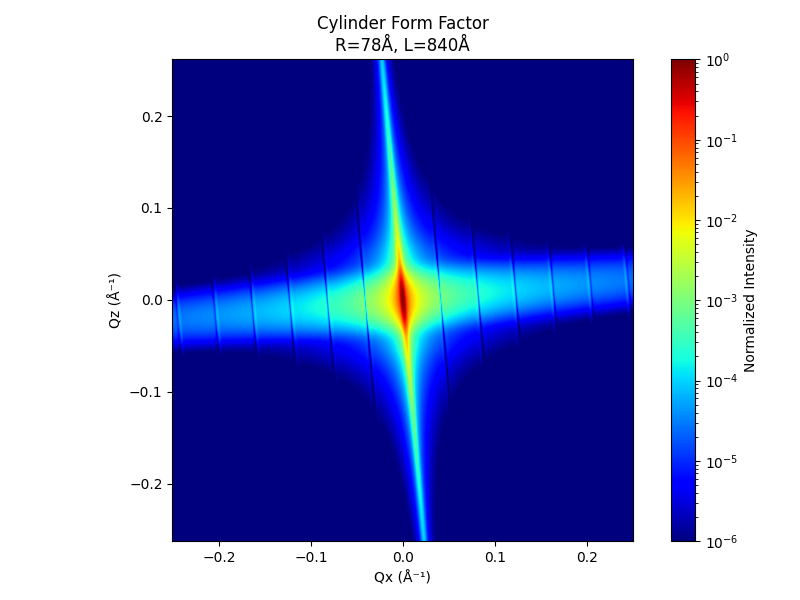


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=94.60_z=20.35_Img0_nematic_determination.png

Fitting results:
x0: 80.5095302522825
S: 0.9255625124204523
R2: 0.9749717558885121

************************************************************************************************************************

 Processing file 2 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_1.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_1.png
Main 

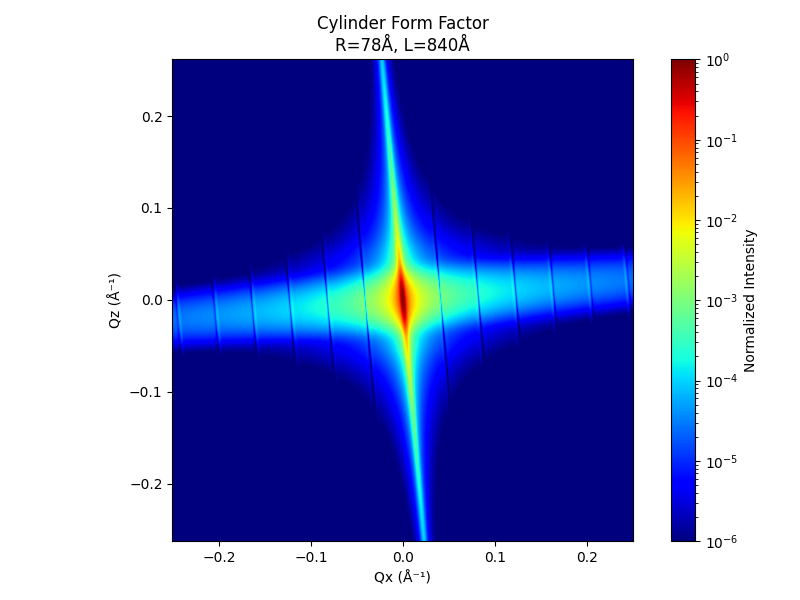


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=140.05_z=20.35_Img1_nematic_determination.png

Fitting results:
x0: 84.04463495737957
S: 0.9453852124343589
R2: 0.9720750972059847

************************************************************************************************************************

 Processing file 3 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_2.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_2.png
Mai

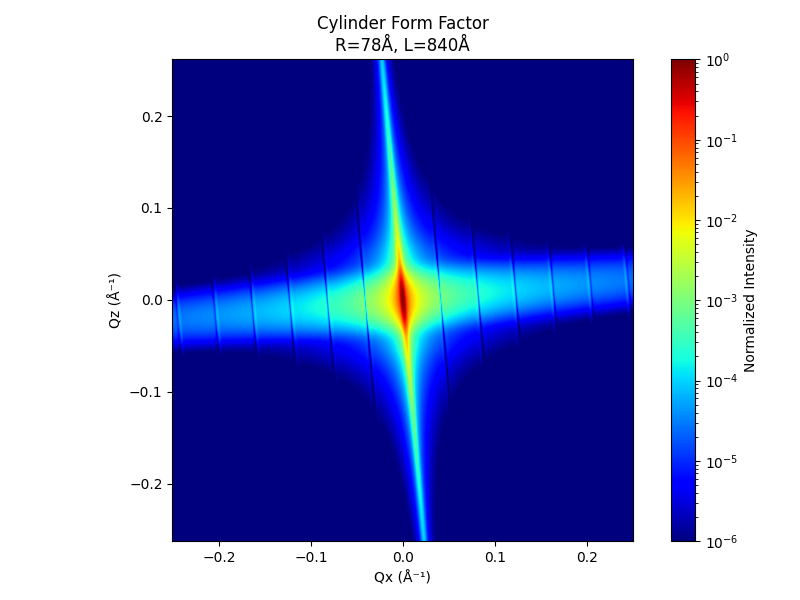


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=185.49_z=20.35_Img2_nematic_determination.png

Fitting results:
x0: 85.28514738658862
S: 0.9487913941809754
R2: 0.9712801382834838

************************************************************************************************************************

 Processing file 4 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_3.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_3.png
Mai

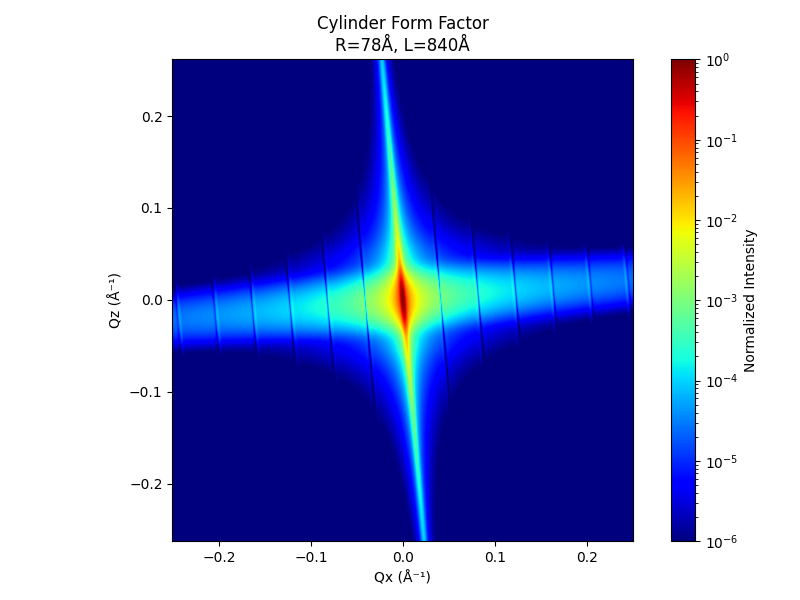


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=230.94_z=20.35_Img3_nematic_determination.png

Fitting results:
x0: 86.87053318796177
S: 0.949339036115221
R2: 0.9712549475620054

************************************************************************************************************************

 Processing file 5 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_4.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_4.png
Main

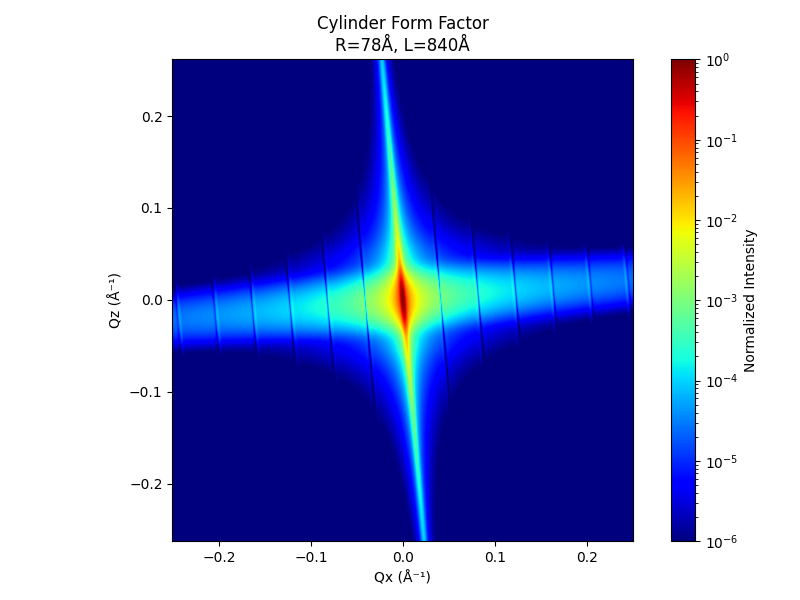


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=276.38_z=20.35_Img4_nematic_determination.png

Fitting results:
x0: 87.81566019736607
S: 0.9502595160217125
R2: 0.9704882309835737

************************************************************************************************************************

 Processing file 6 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_5.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_5.png
Mai

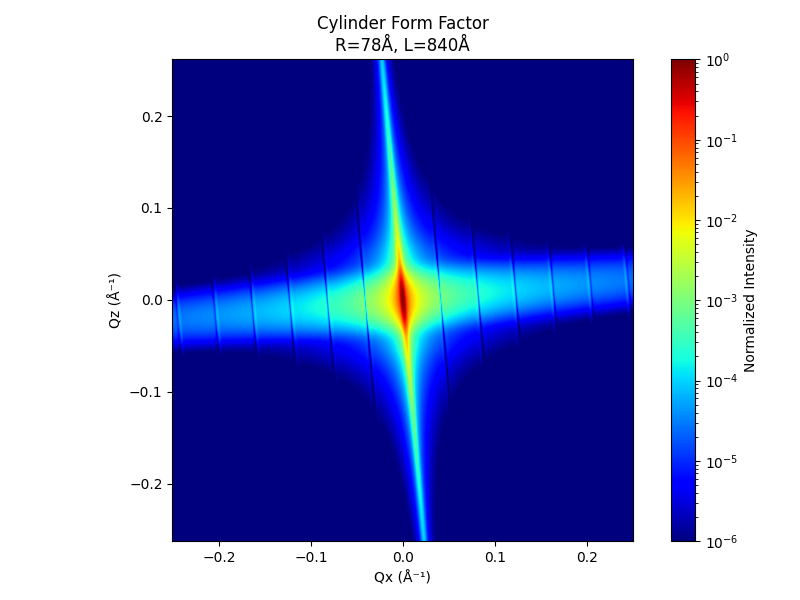


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=321.83_z=20.35_Img5_nematic_determination.png

Fitting results:
x0: 89.147848576419
S: 0.949125772853376
R2: 0.9696238924681743

************************************************************************************************************************

 Processing file 7 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_6.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_6.png
Main n

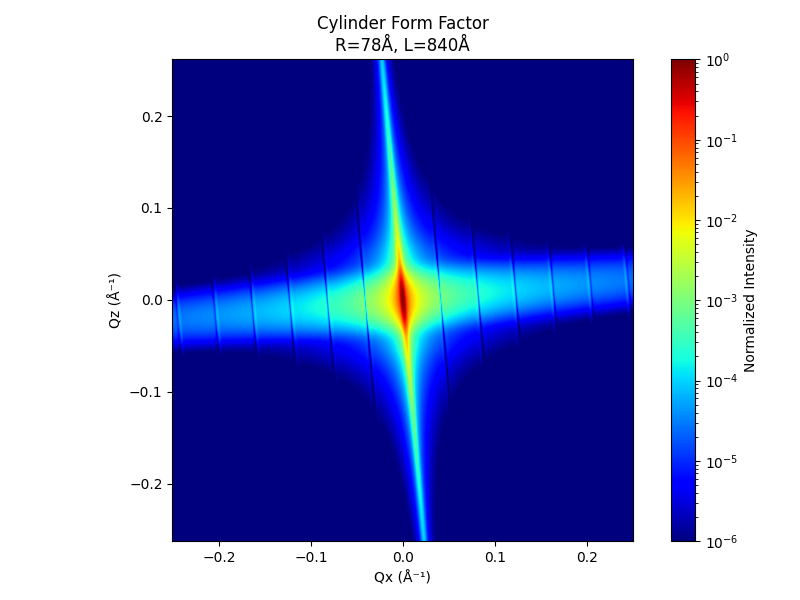


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=367.27_z=20.35_Img6_nematic_determination.png

Fitting results:
x0: 90.2562544262504
S: 0.9481342100674242
R2: 0.9661036203846556

************************************************************************************************************************

 Processing file 8 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_7.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_7.png
Main

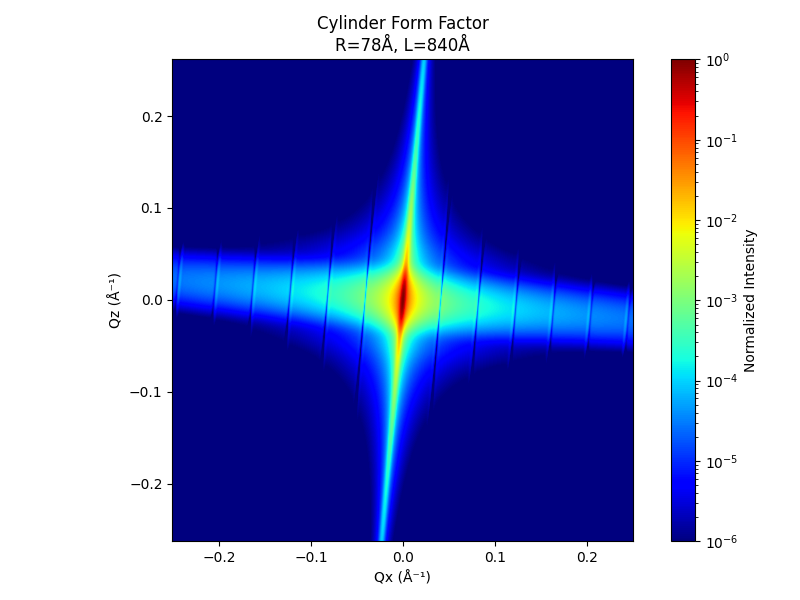


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=412.72_z=20.35_Img7_nematic_determination.png

Fitting results:
x0: -88.78889922155011
S: 0.9453712761260006
R2: 0.9724039508947419

************************************************************************************************************************

 Processing file 9 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_8.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_8.png
Ma

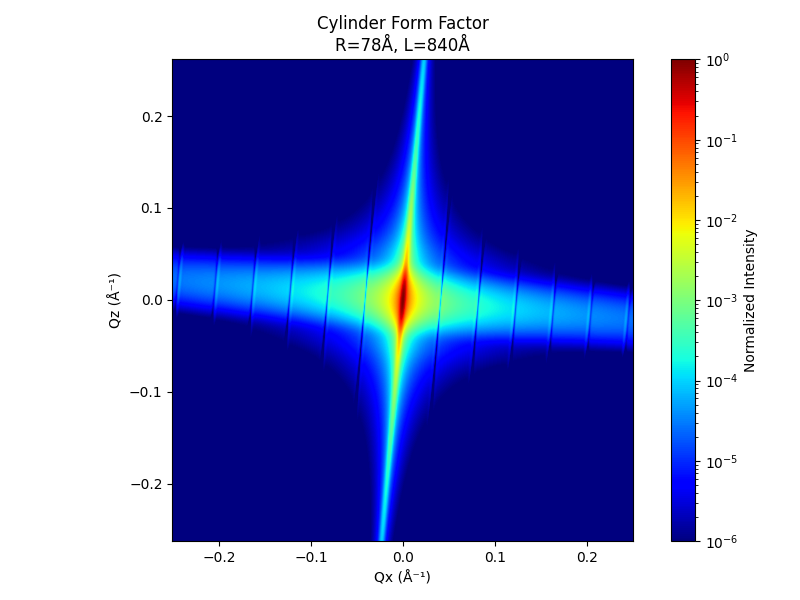


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=458.16_z=20.35_Img8_nematic_determination.png

Fitting results:
x0: -85.17798895964798
S: 0.9450738132204307
R2: 0.9696452334965509

************************************************************************************************************************

 Processing file 10 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_9.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_9.png
M

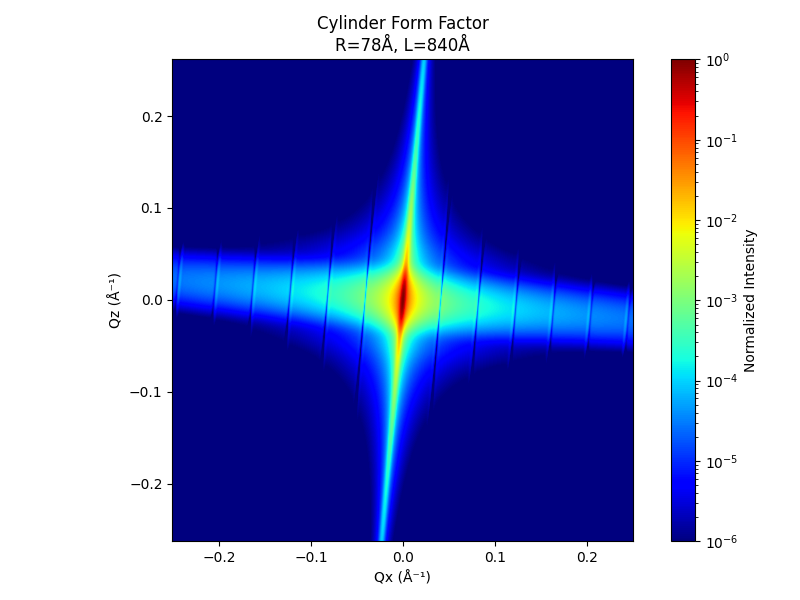


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q


/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py:220: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=503.61_z=20.35_Img9_nematic_determination.png

Fitting results:
x0: -85.97388544410359
S: 0.9448076220314631
R2: 0.9705774670778867

************************************************************************************************************************

 Processing file 11 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_10.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_10.png
Main nanorod orientation is 5.006972872275682

Computing cylinder form factor...


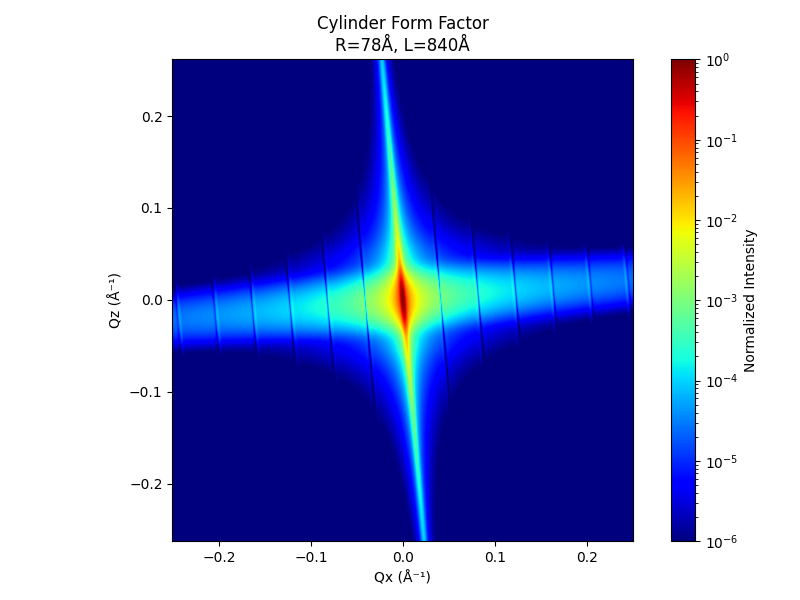


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=549.05_z=20.35_Img10_nematic_determination.png

Fitting results:
x0: 80.81953541891926
S: 0.9000355333802182
R2: 0.9389563576226344


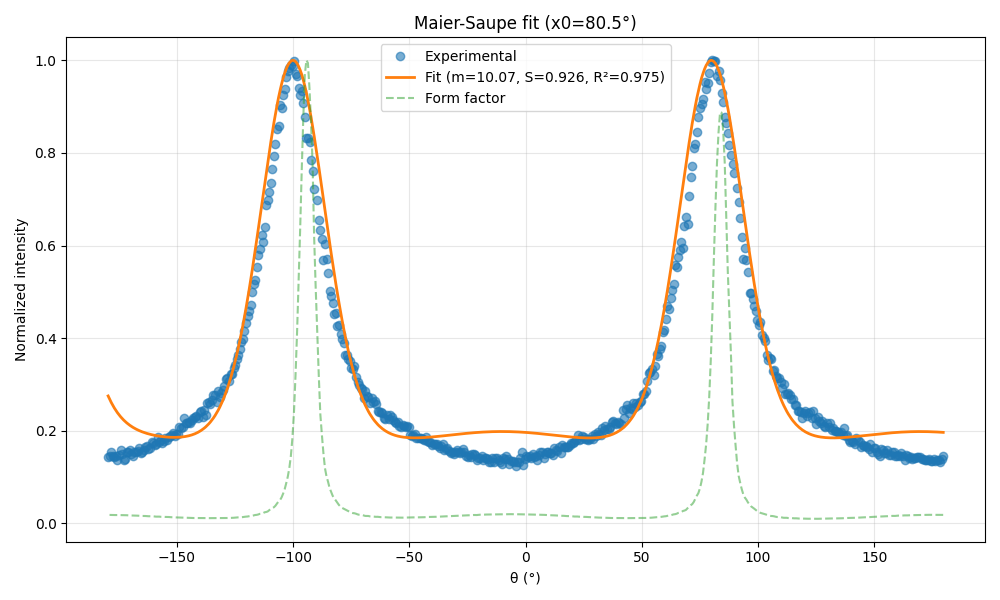

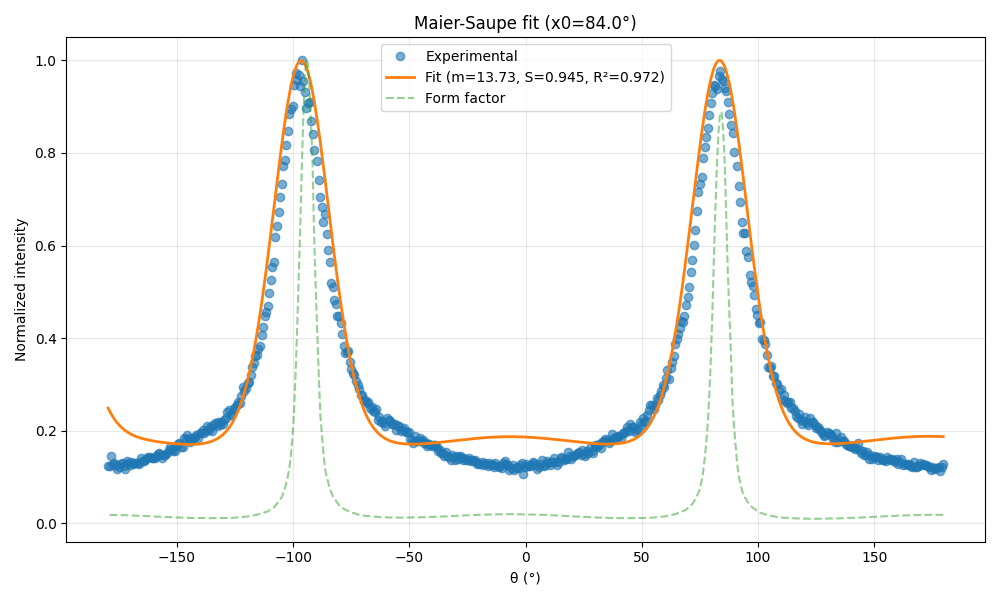

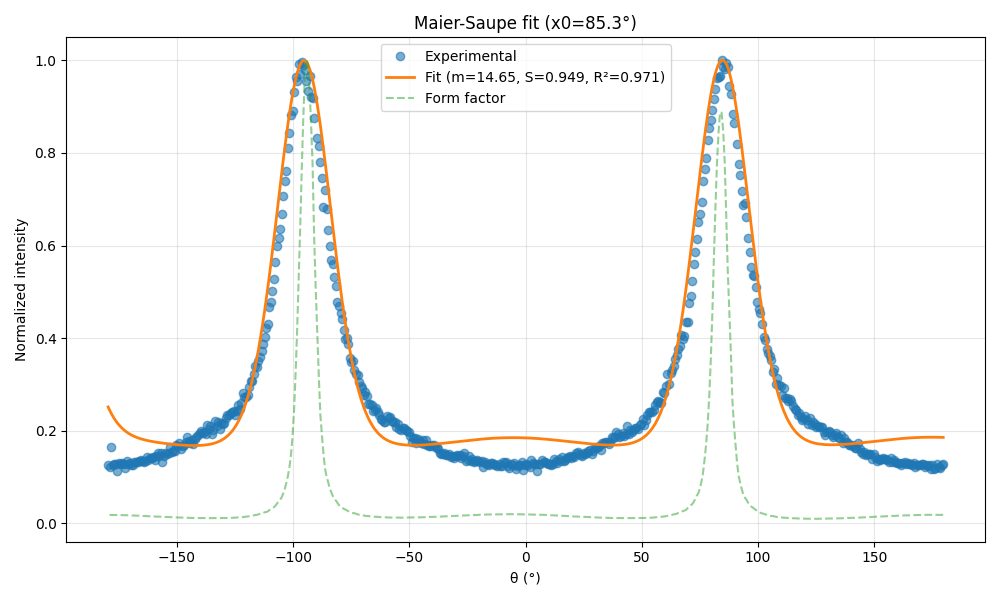

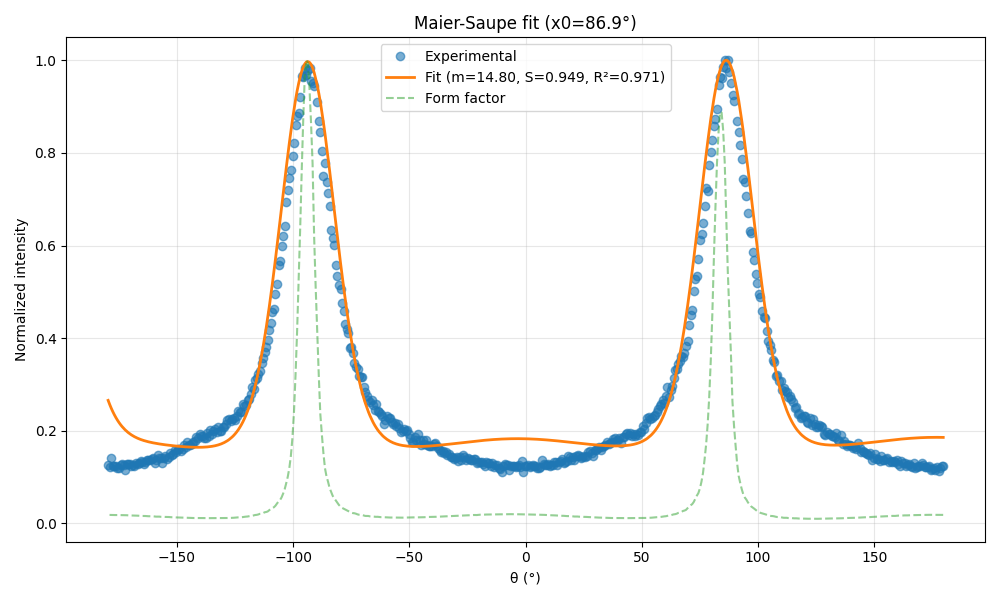

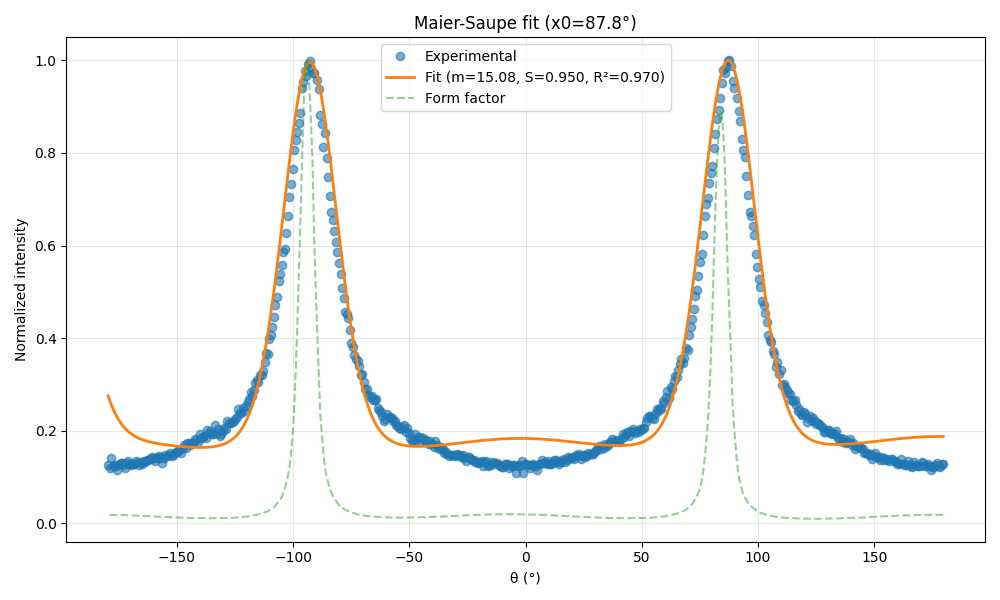

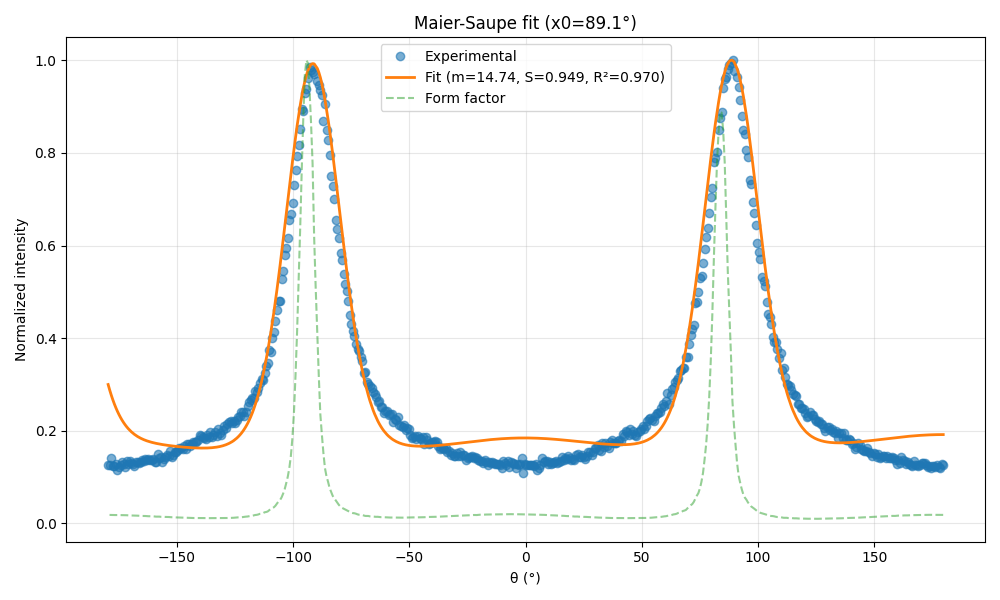

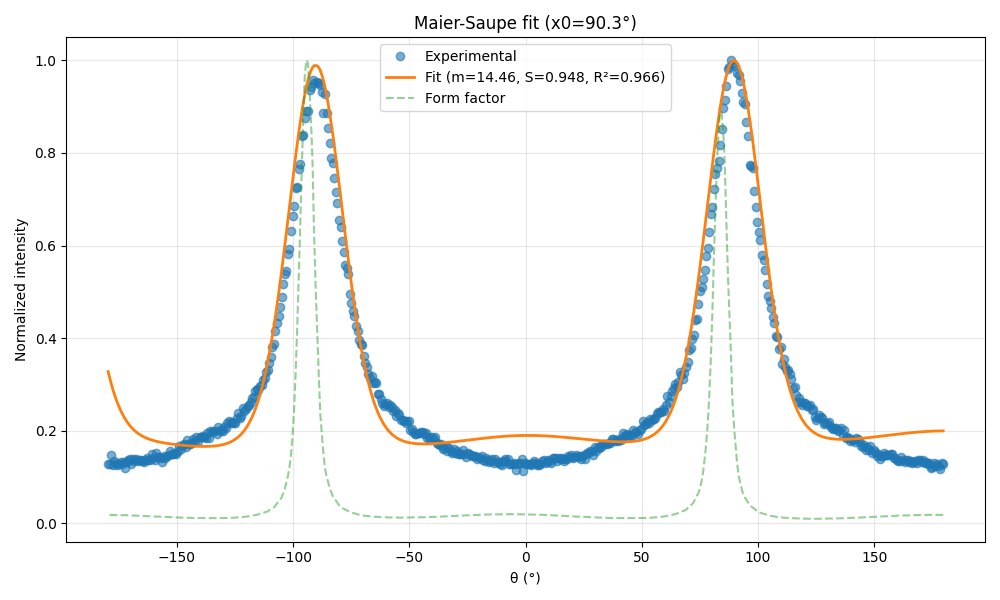

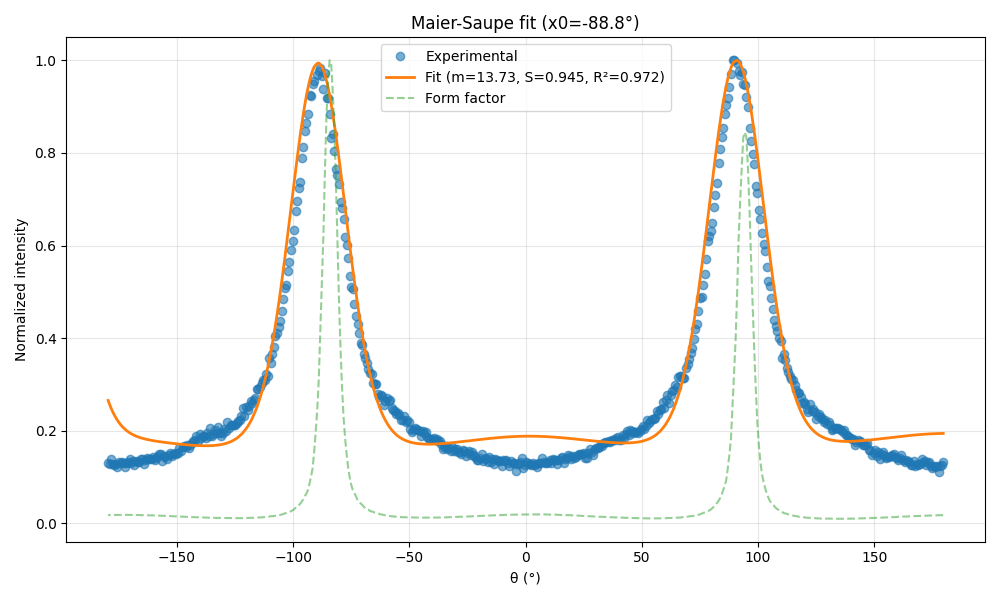

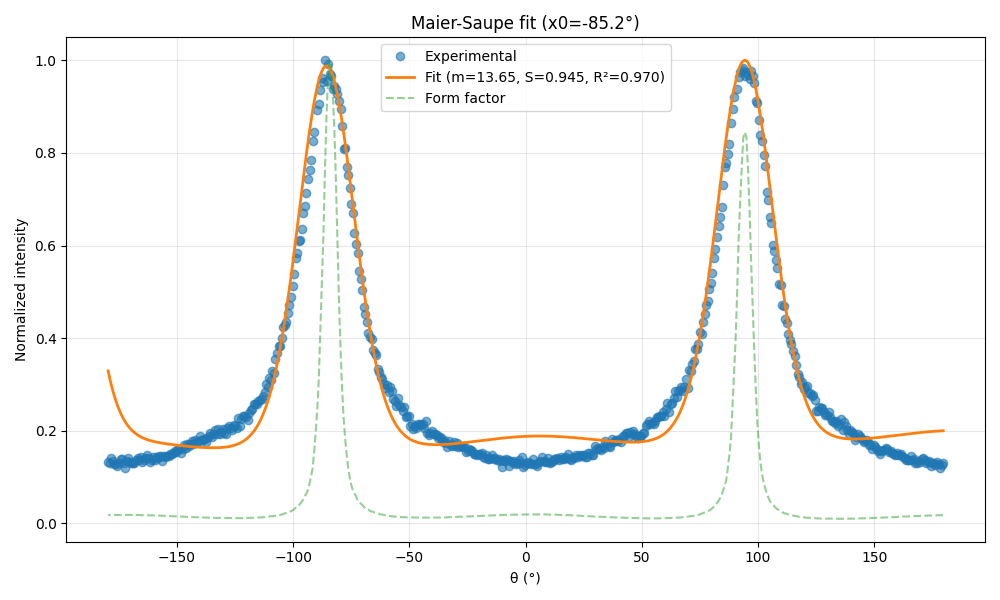

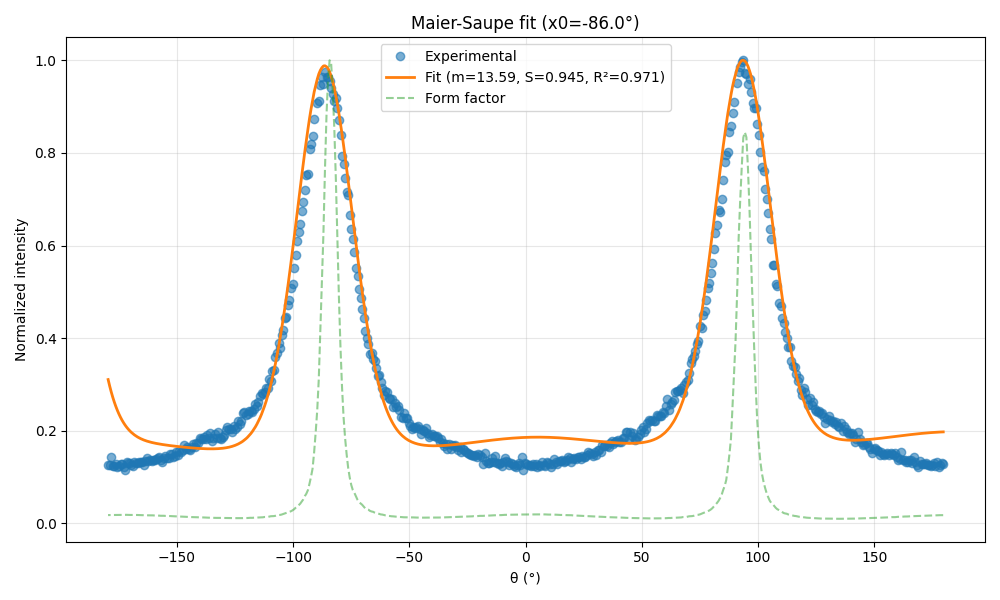

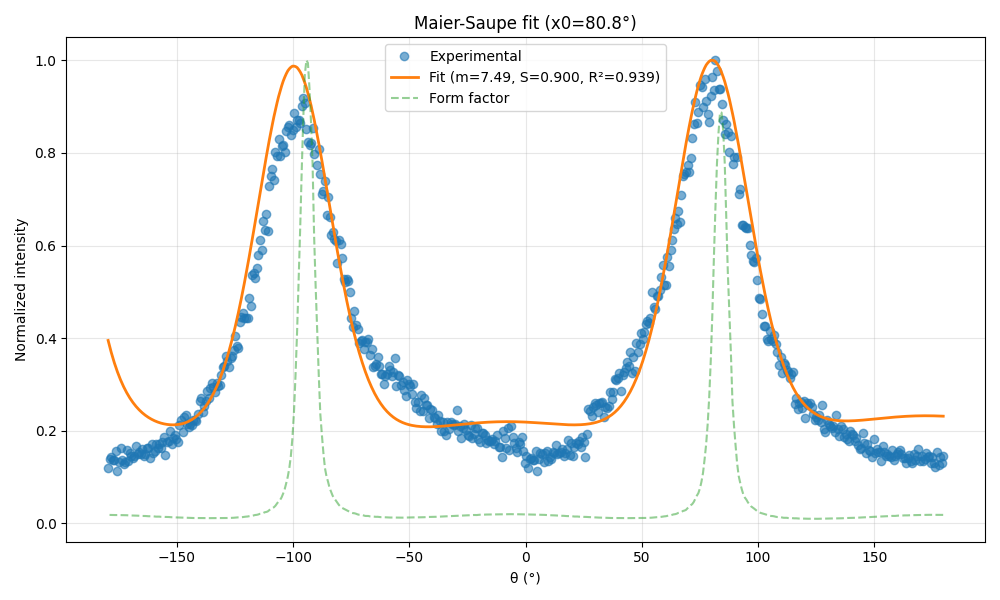

In [4]:
S_array = np.zeros(number_of_images)
x_array = np.zeros(number_of_images)
x0_array = np.zeros(number_of_images)
for i,file in enumerate(filelist): # boulce longue, à parraléliser
    print('\n' + '*'*120)
    print(f'\n Processing file {i+1} / {number_of_images}: {file}')
    print('\n' + '*'*120)
    proc=SAXSProcessor(file, instrument='LGC',mask=mask) # instrument is set to 'LGC' as we are dealing with edf files now.
    proc.plot2d_vsq(q_range=(0,0.15), output_dir=edfpath)
    S,orientation, results = compute_nematic_parameter(processor=proc,plot=True, apply_mirror = False, qvalue = 0.03, threshold=0.05, verbose=True)
    S_array[i] = S
    x_array[i] = proc.x
    x0_array[i] = orientation  # on plie dans l'intervalle [-90,90]

    

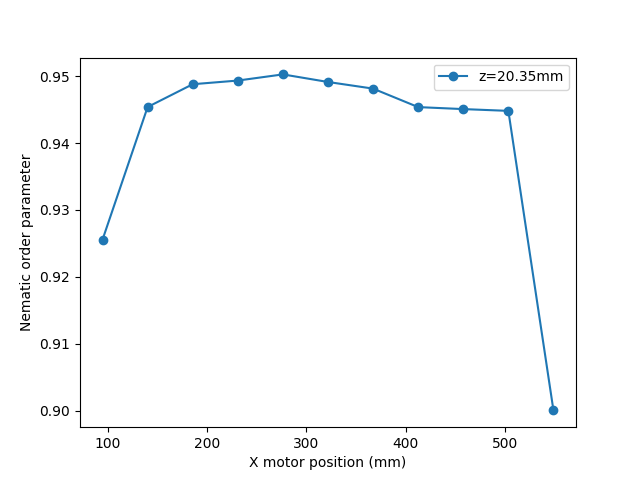

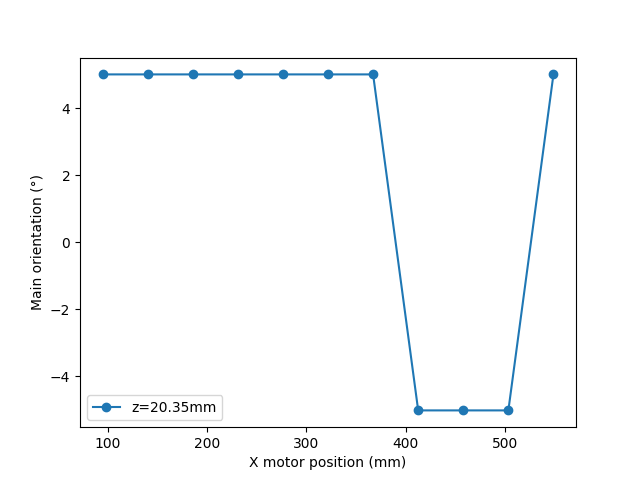

In [5]:
plt.figure()
plt.plot(x_array,S_array, marker ='o', label=f'z={proc.z}mm')
plt.xlabel('X motor position (mm)')
plt.ylabel('Nematic order parameter')
plt.legend()

plt.figure()
plt.plot(x_array,x0_array, marker ='o', label=f'z={proc.z}mm')
plt.xlabel('X motor position (mm)')
plt.ylabel('Main orientation (°)')
plt.legend()

## Essai sur un assemblage complet

**Plot cartographie de transmission**

La fonction prend 2 arguments:

    h5path: chemin d'accès aux fichiers h5 correspondant à l'assemblage

    prefix: (='lacroix par défaut) nom devant le n° dans le nome de fichier h5. 
            Exemple fichier lacroix_00032_20230718.h5 -> prefix = 'lacroix'

Extracting transmission data:   0%|          | 0/5 [00:00<?, ?it/s]

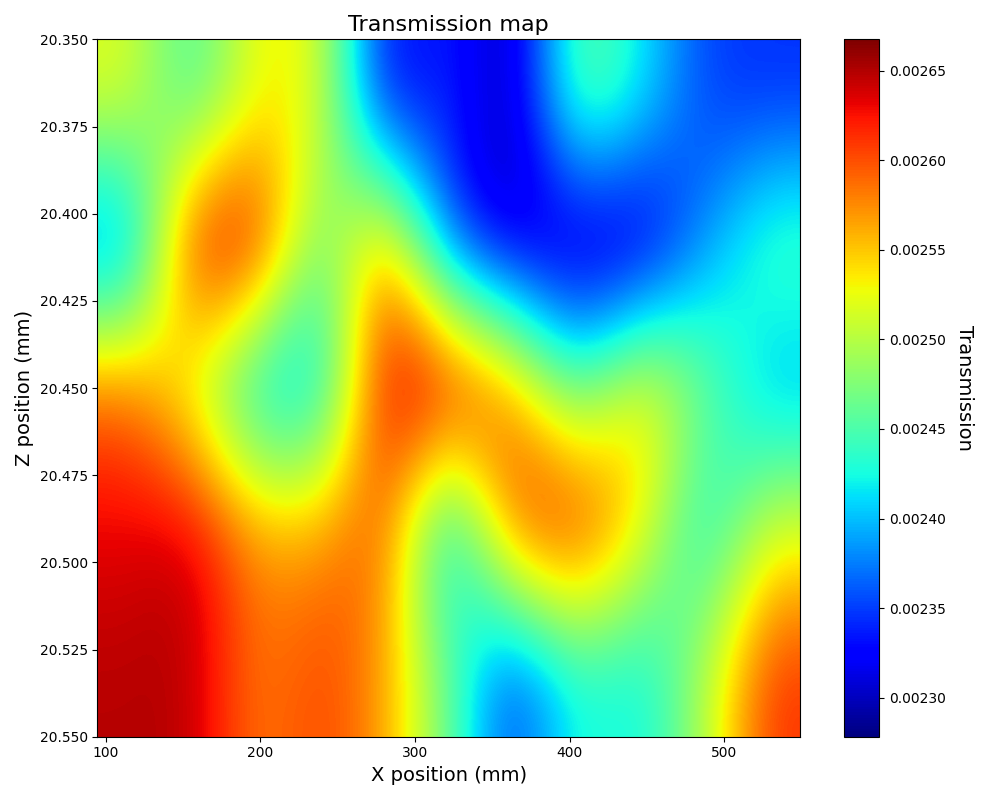

In [6]:
from utilities_SWING import plot_transmission_map
h5path='/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/'
plot_transmission_map(h5path,prefix='lacroix')

**Calcul et plot du paramètre nématique**

Pour le traitement d'un assemblage, il faut connaitre au préalable à quelle valeur de q on veut travailler pour extraire le profile azimuthal. Pour se faire, on va d'abord travailler sur un fichier individuel et extraire un profil radial moyen. Ce n'est pas montré ici car on a traité ci dessus le cas d'un fichier individuel.

Voici les arguments de la fonction utilisée:
    
    h5path: string
        Path to directory where data is stored

    prefix: prefix dans le nom des fichiers h5 (='lacroix' par défaut)
    
    mask:
        Path to mask file

    reference_file: str
        Path to data file corresponding to reference measurement

    autosubstract: bool (default= True)
        Apply automatic reference substraction

    k: float
        Coefficient for reference substraction (ignore if auto_substract is True)
    
    qvalue: float
        q value of interest at which azimuthal profile is extracted
    
    threshold: float
        relative value to defin the q range for azimuthal profile extraction
    
    radius: float
        Cylinder radius for form factor caclulation
    
    L: float
        Cylinder length for form factor calculation
    
    radius_pd, L_pd: float
        Polydispersity ratio for radius and length
    
    plot : bool
        Plot form factor and fitting results
    
    apply_mirror: bool
        Apply mirror symmetry to incomplete exp azimuthal profile

    verbose: bool
        

Dans cet exemple, on n'a pas de mesure de référence, donc les arguments reference_file, autosubstract et k ne sont pas renseignés. 

In [1]:
from utilities_SWING import *
h5path='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs'
#referencefile='path/to/reference/file'  # --- IGNORE ---
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(
    h5path=h5path,
    mask=mask,
    qvalue=0.034,
    threshold=0.05,
    plot=True,
    apply_mirror=False,
    verbose=True)

### Step 2/7
**Extracting frames and converting to EDF files**

FileNotFoundError: [WinError 3] Le chemin d’accès spécifié est introuvable: 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs\\edf_files'

#### **Réédition du plot sur assemblage complet**

On s'appuie ici sur des résultats obtenus précédemment et stockés dans un fichier csv produit par la fonction compute_nematic_order_assembly_SWING.
On applique un filtre sur le critère R2, afin de ne sélectionner que les points pertinents.

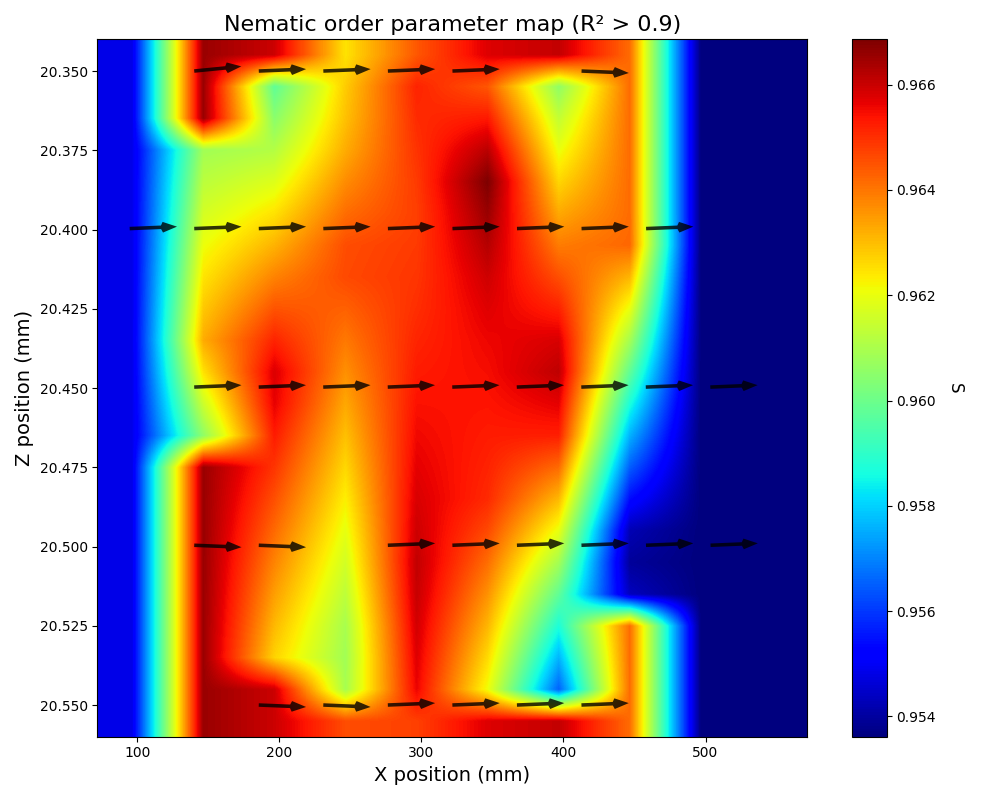

In [8]:
csvpath = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/nematic_processing_results/nematic_order_results.csv'
plot_from_csv(csvpath, R2_threshold=0.9)

**Calcul du paramètre d'ordre nématique global**

On utilise la fonction compute_global_nematic_parameter(). Cette fonction fait dans un premier temps la moyenne de toutes les intensités pour tous les points mesurés. Cette intensité moyenne est ensuite utilisée pour calculer le paramètr d'ordre global.

In [9]:
from utilities_SWING import *
h5path='/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/'
#referencefile='path/to/reference/file'  # --- IGNORE ---
mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask.edf'

S = compute_global_nematic_parameter(
    h5path,
    prefix='lacroix',
    reference_file=None,
    k=1,
    autosubstract=True,
    mask=None,
    qvalue=0.034,
    threshold=0.05,
    radius=78,
    L=840,
    radius_pd=0.3,
    L_pd=0.75,
    plot=False,
    apply_mirror=False,
    verbose=True)

Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04288_2024-07-22_01-32-09.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04289_2024-07-22_01-32-36.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04290_2024-07-22_01-33-04.h5
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Processing /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04291_2024-07-22_01-33-32.h5
No motor positions provided. Update fi